In [4]:
import numpy as np
from scipy.stats import gaussian_kde

def draw_density_blob(ax, points, quantile=0.25, bw=0.3, pad=0.6,
                      gridsize=250, color='black', linewidth=2.0):
    """
    Desenha um contorno suave em volta de uma região densa usando KDE.

    points: array (n, 2)
    quantile: controla o tamanho da região
        - menor -> contorno maior
        - maior -> contorno mais colado no núcleo denso
    bw: bandwidth da KDE
        - menor -> contorno mais irregular
        - maior -> contorno mais suave
    """
    kde = gaussian_kde(points.T, bw_method=bw)

    x_min, y_min = points.min(axis=0) - pad
    x_max, y_max = points.max(axis=0) + pad

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, gridsize),
        np.linspace(y_min, y_max, gridsize)
    )

    grid = np.vstack([xx.ravel(), yy.ravel()])
    zz = kde(grid).reshape(xx.shape)

    # nível baseado na densidade observada nos próprios pontos
    point_density = kde(points.T)
    level = np.quantile(point_density, quantile)

    cs = ax.contour(
        xx, yy, zz,
        levels=[level],
        colors=color,
        linewidths=linewidth
    )

    return cs

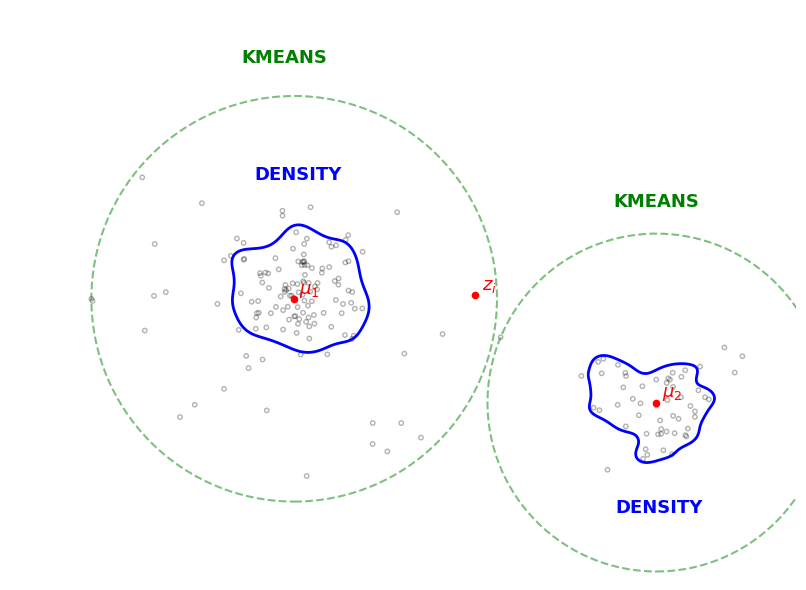

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from sklearn.cluster import KMeans

# ============================================================
# Configuração geral
# ============================================================
rng = np.random.default_rng(7)


# ============================================================
# Funções auxiliares
# ============================================================
def sample_gaussian_layers(center, n_core=90, n_shell=30,
                           core_std=0.30, shell_std=0.75, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    core = rng.normal(loc=center, scale=core_std, size=(n_core, 2))
    shell = rng.normal(loc=center, scale=shell_std, size=(n_shell, 2))
    return core, shell


def sample_annulus(center, n, r_min, r_max, angle_range=(0, 2*np.pi), rng=None):
    if rng is None:
        rng = np.random.default_rng()

    theta = rng.uniform(angle_range[0], angle_range[1], n)
    r = np.sqrt(rng.uniform(r_min**2, r_max**2, n))

    x = center[0] + r * np.cos(theta)
    y = center[1] + r * np.sin(theta)

    return np.column_stack([x, y])


def sample_irregular_blob(center, n=60, base_radius=1.0, noise=0.05, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    theta = rng.uniform(0, 2*np.pi, n)

    radial_shape = (
        base_radius
        + 0.22 * np.sin(3 * theta + 0.5)
        + 0.16 * np.sin(5 * theta - 0.8)
        + rng.normal(0, noise, n)
    )
    radial_shape = np.clip(radial_shape, 0.35, None)

    u = np.sqrt(rng.uniform(0, 1, n))
    r = radial_shape * u

    x = center[0] + 1.15 * r * np.cos(theta)
    y = center[1] + 0.85 * r * np.sin(theta)

    return np.column_stack([x, y])


def min_distance(point, cloud):
    return np.min(np.linalg.norm(cloud - point, axis=1))


# ============================================================
# 1) Construção dos dados
# ============================================================
center1 = np.array([0.0, 0.0])

core1, shell1 = sample_gaussian_layers(
    center=center1,
    n_core=90,
    n_shell=28,
    core_std=0.53,
    shell_std=0.75,
    rng=rng
)

omega1_density = np.vstack([core1, shell1])

noise1 = np.vstack([
    sample_annulus(
        center=center1,
        n=12,
        r_min=1.8,
        r_max=3.6,
        angle_range=(0.70*np.pi, 1.55*np.pi),
        rng=rng
    ),
    sample_annulus(
        center=center1,
        n=7,
        r_min=2.1,
        r_max=3.2,
        angle_range=(1.60*np.pi, 1.95*np.pi),
        rng=rng
    )
])

center2 = np.array([5.4, -1.7])

# omega2 original continua sendo usado no KMeans
omega2 = sample_irregular_blob(
    center=center2,
    n=55,
    base_radius=0.95,
    noise=0.18,
    rng=rng
)

# pontos extras só para alargar visualmente a mancha da direita
omega2_right_tail = sample_irregular_blob(
    center=center2 + np.array([-0.38, 0.00]),  # controla o quanto vai para a direita
    n=18,                                     # controla o quanto essa "cauda" pesa
    base_radius=0.35,
    noise=0.02,
    rng=rng
)

# conjunto só para desenhar a região de densidade
omega2_density_visual = np.vstack([omega2, omega2_right_tail])



# ============================================================
# ponto z_i com controle manual
# ============================================================
zi_dx = 2.6
zi_dy = -0.15

zi = center1 + np.array([zi_dx, zi_dy])

# Todos os pontos usados no KMeans
all_points = np.vstack([core1, shell1, noise1, omega2, zi.reshape(1, 2)])


# ============================================================
# 2) KMeans com 2 grupos
# ============================================================
kmeans = KMeans(n_clusters=2, random_state=7, n_init=20)
labels = kmeans.fit_predict(all_points)
centers = kmeans.cluster_centers_

# ordenar clusters da esquerda para a direita
order = np.argsort(centers[:, 0])


# ============================================================
# 3) Plot
# ============================================================
fig, ax = plt.subplots(figsize=(10, 6))

point_style = dict(
    s=10,
    facecolors='none',
    edgecolors='black',
    linewidths=1.0,
    alpha=0.3
)

# todos os pontos
ax.scatter(all_points[:, 0], all_points[:, 1], **point_style)

# destacar z_i
ax.scatter(*zi, c='red', s=20, marker='o', zorder=5)
ax.text(zi[0] + 0.10, zi[1] + 0.08, r'$z_i$', fontsize=13, c='red')

# guardar info dos círculos
circle_infos = []

# desenhar círculo de cada cluster com raio máximo
for new_idx, old_k in enumerate(order, start=1):
    cluster_points = all_points[labels == old_k]
    center = centers[old_k]

    distances = np.linalg.norm(cluster_points - center, axis=1)
    radius = distances.max()

    circle = Circle(
        xy=center,
        radius=radius,
        fill=False,
        edgecolor='green',
        linewidth=1.5,
        linestyle='--',
        alpha=0.5
    )
    ax.add_patch(circle)

    circle_infos.append((center, radius))

    # centróide
    ax.scatter(center[0], center[1], c='red', s=20, marker='o', zorder=6)
    ax.text(center[0] + 0.08, center[1] + 0.08, rf'$\mu_{new_idx}$', fontsize=13, c='red')


# contorno da região densa da esquerda
draw_density_blob(
    ax,
    core1,
    quantile=0.1,
    bw=0.5,
    color='blue',
    linewidth=2.0
)

# contorno da região densa da direita
draw_density_blob(
    ax,
    omega2_density_visual,
    quantile=0.08,
    bw=0.32,
    color='blue',
    linewidth=2.0
)

# ============================================================
# 4) Rótulos "fora" das regiões
# ============================================================

# --- KMEANS: um rótulo perto de cada círculo ---
(left_center, left_radius), (right_center, right_radius) = circle_infos

ax.text(
    left_center[0] - 0.15,
    left_center[1] + left_radius + 0.45,
    'KMEANS',
    color='green',
    fontsize=13,
    fontweight='bold',
    ha='center',
    va='bottom'
)

ax.text(
    right_center[0],
    right_center[1] + right_radius + 0.35,
    'KMEANS',
    color='green',
    fontsize=13,
    fontweight='bold',
    ha='center',
    va='bottom'
)

# --- DENSITY: um rótulo perto de cada mancha ---
core1_center = core1.mean(axis=0)
omega2_center = omega2.mean(axis=0)

ax.text(
    core1_center[0],
    core1[:, 1].max() + 0.35,
    'DENSITY',
    color='blue',
    fontsize=13,
    fontweight='bold',
    ha='center',
    va='bottom'
)

ax.text(
    omega2_center[0],
    omega2[:, 1].min() - 0.45,
    'DENSITY',
    color='blue',
    fontsize=13,
    fontweight='bold',
    ha='center',
    va='top'
)

ax.set_aspect('equal')
ax.set_xlim(-4.5, 7.5)
ax.set_ylim(-4.5, 4.2)
ax.axis('off')

plt.tight_layout()
plt.show()

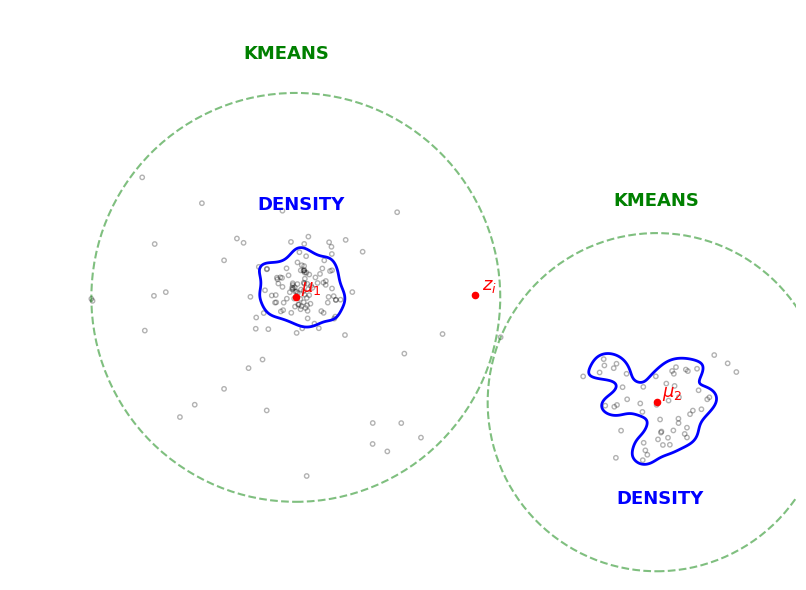

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from sklearn.cluster import KMeans

# ============================================================
# Configuração geral
# ============================================================
rng = np.random.default_rng(7)


# ============================================================
# Funções auxiliares
# ============================================================
def sample_gaussian_layers(center, n_core=90, n_shell=30,
                           core_std=0.30, shell_std=0.75, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    core = rng.normal(loc=center, scale=core_std, size=(n_core, 2))
    shell = rng.normal(loc=center, scale=shell_std, size=(n_shell, 2))
    return core, shell


def sample_annulus(center, n, r_min, r_max, angle_range=(0, 2*np.pi), rng=None):
    if rng is None:
        rng = np.random.default_rng()

    theta = rng.uniform(angle_range[0], angle_range[1], n)
    r = np.sqrt(rng.uniform(r_min**2, r_max**2, n))

    x = center[0] + r * np.cos(theta)
    y = center[1] + r * np.sin(theta)

    return np.column_stack([x, y])


def sample_irregular_blob(center, n=60, base_radius=1.0, noise=0.05, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    theta = rng.uniform(0, 2*np.pi, n)

    radial_shape = (
        base_radius
        + 0.22 * np.sin(3 * theta + 0.5)
        + 0.16 * np.sin(5 * theta - 0.8)
        + rng.normal(0, noise, n)
    )
    radial_shape = np.clip(radial_shape, 0.35, None)

    u = np.sqrt(rng.uniform(0, 1, n))
    r = radial_shape * u

    x = center[0] + 1.15 * r * np.cos(theta)
    y = center[1] + 0.85 * r * np.sin(theta)

    return np.column_stack([x, y])


def min_distance(point, cloud):
    return np.min(np.linalg.norm(cloud - point, axis=1))


# ============================================================
# 1) Construção dos dados
# ============================================================
center1 = np.array([0.0, 0.0])

core1, shell1 = sample_gaussian_layers(
    center=center1,
    n_core=90,
    n_shell=28,
    core_std=0.33,
    shell_std=0.75,
    rng=rng
)

omega1_density = np.vstack([core1, shell1])

noise1 = np.vstack([
    sample_annulus(
        center=center1,
        n=12,
        r_min=1.8,
        r_max=3.6,
        angle_range=(0.70*np.pi, 1.55*np.pi),
        rng=rng
    ),
    sample_annulus(
        center=center1,
        n=7,
        r_min=2.1,
        r_max=3.2,
        angle_range=(1.60*np.pi, 1.95*np.pi),
        rng=rng
    )
])

center2 = np.array([5.4, -1.7])

omega2 = sample_irregular_blob(
    center=center2,
    n=55,
    base_radius=0.95,
    noise=0.05,
    rng=rng
)

# ============================================================
# ponto z_i com controle manual
# ============================================================
zi_dx = 2.6
zi_dy = -0.15

zi = center1 + np.array([zi_dx, zi_dy])

# Todos os pontos usados no KMeans
all_points = np.vstack([core1, shell1, noise1, omega2, zi.reshape(1, 2)])


# ============================================================
# 2) KMeans com 2 grupos
# ============================================================
kmeans = KMeans(n_clusters=2, random_state=7, n_init=20)
labels = kmeans.fit_predict(all_points)
centers = kmeans.cluster_centers_

# ordenar clusters da esquerda para a direita
order = np.argsort(centers[:, 0])


# ============================================================
# 3) Plot
# ============================================================
fig, ax = plt.subplots(figsize=(10, 6))

point_style = dict(
    s=10,
    facecolors='none',
    edgecolors='black',
    linewidths=1.0,
    alpha=0.3
)

# todos os pontos
ax.scatter(all_points[:, 0], all_points[:, 1], **point_style)

# destacar z_i
ax.scatter(*zi, c='red', s=20, marker='o', zorder=5)
ax.text(zi[0] + 0.10, zi[1] + 0.08, r'$z_i$', fontsize=13, c='red')

# guardar info dos círculos
circle_infos = []

# desenhar círculo de cada cluster com raio máximo
for new_idx, old_k in enumerate(order, start=1):
    cluster_points = all_points[labels == old_k]
    center = centers[old_k]

    distances = np.linalg.norm(cluster_points - center, axis=1)
    radius = distances.max()

    circle = Circle(
        xy=center,
        radius=radius,
        fill=False,
        edgecolor='green',
        linewidth=1.5,
        linestyle='--',
        alpha=0.5
    )
    ax.add_patch(circle)

    circle_infos.append((center, radius))

    # centróide
    ax.scatter(center[0], center[1], c='red', s=20, marker='o', zorder=6)
    ax.text(center[0] + 0.08, center[1] + 0.08, rf'$\mu_{new_idx}$', fontsize=13, c='red')


# contorno da região densa da esquerda
draw_density_blob(
    ax,
    core1,
    quantile=0.1,
    bw=0.5,
    color='blue',
    linewidth=2.0
)

# contorno da região densa da direita
draw_density_blob(
    ax,
    omega2,
    quantile=0.1,
    bw=0.3,
    color='blue',
    linewidth=2.0
)

# ============================================================
# 4) Rótulos "fora" das regiões
# ============================================================

# --- KMEANS: um rótulo perto de cada círculo ---
(left_center, left_radius), (right_center, right_radius) = circle_infos

ax.text(
    left_center[0] - 0.15,
    left_center[1] + left_radius + 0.45,
    'KMEANS',
    color='green',
    fontsize=13,
    fontweight='bold',
    ha='center',
    va='bottom'
)

ax.text(
    right_center[0],
    right_center[1] + right_radius + 0.35,
    'KMEANS',
    color='green',
    fontsize=13,
    fontweight='bold',
    ha='center',
    va='bottom'
)

# --- DENSITY: um rótulo perto de cada mancha ---
core1_center = core1.mean(axis=0)
omega2_center = omega2.mean(axis=0)

ax.text(
    core1_center[0],
    core1[:, 1].max() + 0.35,
    'DENSITY',
    color='blue',
    fontsize=13,
    fontweight='bold',
    ha='center',
    va='bottom'
)

ax.text(
    omega2_center[0],
    omega2[:, 1].min() - 0.45,
    'DENSITY',
    color='blue',
    fontsize=13,
    fontweight='bold',
    ha='center',
    va='top'
)

ax.set_aspect('equal')
ax.set_xlim(-4.5, 7.5)
ax.set_ylim(-4.5, 4.2)
ax.axis('off')

plt.tight_layout()
plt.show()

In [10]:
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt
import numpy as np


def polygon_area(points):
    x = points[:, 0]
    y = points[:, 1]
    return 0.5 * np.abs(np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1)))


def density_blob_path(points, quantile=0.1, bw=0.3, pad=0.8, gridsize=300):
    """
    Retorna um único contorno fechado da região densa, para exportação em TikZ.
    """
    kde = gaussian_kde(points.T, bw_method=bw)

    x_min, y_min = points.min(axis=0) - pad
    x_max, y_max = points.max(axis=0) + pad

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, gridsize),
        np.linspace(y_min, y_max, gridsize)
    )

    grid = np.vstack([xx.ravel(), yy.ravel()])
    zz = kde(grid).reshape(xx.shape)

    point_density = kde(points.T)
    level = np.quantile(point_density, quantile)

    fig_tmp, ax_tmp = plt.subplots()
    cs = ax_tmp.contour(xx, yy, zz, levels=[level])
    segs = cs.allsegs[0]
    plt.close(fig_tmp)

    if len(segs) == 0:
        return None

    seg = max(segs, key=polygon_area)
    seg = np.vstack([seg, seg[0]])  # fecha o contorno
    return seg


def coords_to_tikz(points):
    return "\n".join(f"    ({x:.4f},{y:.4f})" for x, y in points)


def export_tikz_figure(
    filename,
    all_points,
    zi,
    circle_infos,
    left_blob,
    right_blob,
    core1,
    omega2,
    xmin=-4.5,
    xmax=7.5,
    ymin=-4.5,
    ymax=4.2,
):
    with open(filename, "w", encoding="utf-8") as f:
        f.write(r"""\begin{tikzpicture}
\begin{axis}[
    width=0.95\linewidth,
    height=0.58\linewidth,
    axis equal image,
    hide axis,
    xmin=""" + f"{xmin}" + r""",
    xmax=""" + f"{xmax}" + r""",
    ymin=""" + f"{ymin}" + r""",
    ymax=""" + f"{ymax}" + r""",
    clip=false
]
""")

        # Pontos
        f.write(r"""
\addplot[
    only marks,
    mark=o,
    mark size=0.9pt,
    draw=black,
    fill=white,
    opacity=0.30,
    line width=0.25pt
] coordinates {
""")
        f.write(coords_to_tikz(all_points))
        f.write("\n};\n\n")

        # Círculos do KMeans + centróides
        for idx, (center, radius) in enumerate(circle_infos, start=1):
            cx, cy = center
            f.write(
rf"""\addplot[
    green!60!black,
    dashed,
    opacity=0.50,
    line width=0.8pt,
    domain=0:360,
    samples=220
] ({{{cx:.4f} + {radius:.4f}*cos(x)}}, {{{cy:.4f} + {radius:.4f}*sin(x)}});

\addplot[
    only marks,
    mark=*,
    mark size=1.3pt,
    color=red
] coordinates {{
    ({cx:.4f},{cy:.4f})
}};

\node[text=red] at (axis cs:{cx + 0.18:.4f},{cy + 0.14:.4f}) {{$\mu_{idx}$}};

"""
            )

        # z_i
        f.write(
rf"""\addplot[
    only marks,
    mark=*,
    mark size=1.3pt,
    color=red
] coordinates {{
    ({zi[0]:.4f},{zi[1]:.4f})
}};

\node[text=red] at (axis cs:{zi[0] + 0.18:.4f},{zi[1] + 0.14:.4f}) {{$z_i$}};

"""
        )

        # Manchas de densidade
        if left_blob is not None:
            f.write(r"""
\addplot[
    blue,
    line width=1.0pt
] coordinates {
""")
            f.write(coords_to_tikz(left_blob))
            f.write("\n};\n\n")

        if right_blob is not None:
            f.write(r"""
\addplot[
    blue,
    line width=1.0pt
] coordinates {
""")
            f.write(coords_to_tikz(right_blob))
            f.write("\n};\n\n")

        # Rótulos
        (left_center, left_radius), (right_center, right_radius) = circle_infos
        core1_center = core1.mean(axis=0)
        omega2_center = omega2.mean(axis=0)

        f.write(
rf"""\node[text=green!60!black, font=\bfseries] at (axis cs:{left_center[0] - 0.15:.4f},{left_center[1] + left_radius + 0.45:.4f}) {{KMEANS}};
\node[text=green!60!black, font=\bfseries] at (axis cs:{right_center[0]:.4f},{right_center[1] + right_radius + 0.35:.4f}) {{KMEANS}};

\node[text=blue, font=\bfseries] at (axis cs:{core1_center[0]:.4f},{core1[:,1].max() + 0.35:.4f}) {{DENSITY}};
\node[text=blue, font=\bfseries] at (axis cs:{omega2_center[0]:.4f},{omega2[:,1].min() - 0.45:.4f}) {{DENSITY}};

\endaxis
\endtikzpicture
"""
        )


# ------------------------------------------------------------
# Gere os contornos da densidade com os mesmos parâmetros
# do seu plot atual
# ------------------------------------------------------------
left_blob = density_blob_path(core1, quantile=0.1, bw=0.5)
right_blob = density_blob_path(omega2, quantile=0.1, bw=0.3)

# ------------------------------------------------------------
# Exporte para um arquivo .tex
# ------------------------------------------------------------
export_tikz_figure(
    "kmeans_density_figure.tex",
    all_points=all_points,
    zi=zi,
    circle_infos=circle_infos,
    left_blob=left_blob,
    right_blob=right_blob,
    core1=core1,
    omega2=omega2
)

print("Arquivo salvo: kmeans_density_figure.tex")

Arquivo salvo: kmeans_density_figure.tex
